# 1. Import Library

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, log_loss, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

# 2. Load Dataset

In [2]:
uploaded = files.upload()

df = pd.read_csv("loan_data_2007_2014.csv")

print(f"Data shape: {df.shape}")

Saving loan_data_2007_2014.csv to loan_data_2007_2014.csv
Data shape: (466285, 75)


# 3. Data Understanding

## 3.1 Head of Data

In [3]:
print('Head of Data:')
display(df.head())

Head of Data:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.2 Dataset Information

In [4]:
print("Dataset Information:")
df.info(verbose=True)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 n

## 3.3 Statistical Summary

In [5]:
print('Statistical Summary:')
display(df.describe())

Statistical Summary:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


## 3.4 Unique Values Each Column

In [6]:
print('Unique Values:')
print(df.nunique().to_string())

Unique Values:
Unnamed: 0                     466285
id                             466285
member_id                      466285
loan_amnt                        1352
funded_amnt                      1354
funded_amnt_inv                  9854
term                                2
int_rate                          506
installment                     55622
grade                               7
sub_grade                          35
emp_title                      205475
emp_length                         11
home_ownership                      6
annual_inc                      31901
verification_status                 3
issue_d                            91
loan_status                         9
pymnt_plan                          2
url                            466285
desc                           124435
purpose                            14
title                           63098
zip_code                          888
addr_state                         50
dti                              39

## 3.5 Missing Values Check

In [7]:
print("Missing Values:")
print(df.isnull().sum().to_string())

Missing Values:
Unnamed: 0                          0
id                                  0
member_id                           0
loan_amnt                           0
funded_amnt                         0
funded_amnt_inv                     0
term                                0
int_rate                            0
installment                         0
grade                               0
sub_grade                           0
emp_title                       27588
emp_length                      21008
home_ownership                      0
annual_inc                          4
verification_status                 0
issue_d                             0
loan_status                         0
pymnt_plan                          0
url                                 0
desc                           340304
purpose                             0
title                              21
zip_code                            0
addr_state                          0
dti                               

## 3.6 Duplicate Check

In [8]:
duplicates = df[df.duplicated()]
print(f'Jumlah duplikat di data: {len(duplicates)}')

Jumlah duplikat di data: 0


# 4. Data Cleaning

## 4.1 Feature Engineering

### Drop column

In [9]:
columns_to_drop = [
    'Unnamed: 0',
    'id',
    'member_id',
    'url',
    'desc',
    'zip_code',
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'open_acc_6m',
    'open_il_6m',
    'open_il_12m',
    'open_il_24m',
    'mths_since_rcnt_il',
    'mths_since_last_record',
    'total_bal_il',
    'il_util',
    'open_rv_12m',
    'open_rv_24m',
    'max_bal_bc',
    'all_util',
    'inq_fi',
    'total_cu_tl',
    'inq_last_12m',
    'grade',
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'last_credit_pull_d'
]

df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    466285 non-null  int64  
 1   funded_amnt                  466285 non-null  int64  
 2   funded_amnt_inv              466285 non-null  float64
 3   term                         466285 non-null  object 
 4   int_rate                     466285 non-null  float64
 5   installment                  466285 non-null  float64
 6   sub_grade                    466285 non-null  object 
 7   emp_title                    438697 non-null  object 
 8   emp_length                   445277 non-null  object 
 9   home_ownership               466285 non-null  object 
 10  annual_inc                   466281 non-null  float64
 11  verification_status          466285 non-null  object 
 12  issue_d                      466285 non-null  object 
 13 

### Defining Target Variable

In [11]:
percentage_loan_status = df.loan_status.value_counts(normalize=True) * 100
percentage_loan_status

,proportion
loan_status,
Current,48.087757
Fully Paid,39.619332
Charged Off,9.109236
Late (31-120 days),1.479782
In Grace Period,0.674695
Does not meet the credit policy. Status:Fully Paid,0.426349
Late (16-30 days),0.261214
Default,0.178432
Does not meet the credit policy. Status:Charged Off,0.163205


In [12]:
bad_status = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)'
]

df['bad_flag'] = df['loan_status'].isin(bad_status).astype(int)

In [13]:
percentage_bad_flag = df['bad_flag'].value_counts(normalize=True) * 100
percentage_bad_flag

,proportion
bad_flag,
0,89.069346
1,10.930654


In [14]:
df.drop('loan_status', axis=1, inplace=True)

### Column: 'emp_length_int'

In [15]:
df['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [16]:
df['emp_length_int'] = pd.to_numeric(df['emp_length'].str.replace(r'\D', '', regex=True), errors='coerce')
df['emp_length_int'].head()

,emp_length_int
0,10.0
1,1.0
2,10.0
3,10.0
4,1.0


In [17]:
df.drop('emp_length', axis=1, inplace=True)

### Column: 'term_int'

In [18]:
unique_terms = df['term'].unique()
unique_terms

array([' 36 months', ' 60 months'], dtype=object)

In [19]:
df['term_int'] = df['term'].str.replace(' months', '').astype(int)
df['term_int'].head()

,term_int
0,36
1,60
2,36
3,36
4,60


In [20]:
df.drop('term', axis=1, inplace=True)

### Column: 'mths_since_earliest_cr_line'

In [21]:
df['earliest_cr_line'].head()

,earliest_cr_line
0,Jan-85
1,Apr-99
2,Nov-01
3,Feb-96
4,Jan-96


In [22]:
df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format = '%b-%y')
df['earliest_cr_line_date'].head()

,earliest_cr_line_date
0,1985-01-01
1,1999-04-01
2,2001-11-01
3,1996-02-01
4,1996-01-01


In [23]:
df['mths_since_earliest_cr_line'] = round((pd.to_datetime('2017-12-01') - df['earliest_cr_line_date']).dt.days / 30.5)
df['mths_since_earliest_cr_line'].head()

,mths_since_earliest_cr_line
0,394.0
1,224.0
2,193.0
3,261.0
4,262.0


In [24]:
df[df['mths_since_earliest_cr_line'] < 0][['earliest_cr_line', 'earliest_cr_line_date', 'mths_since_earliest_cr_line']].head()

,earliest_cr_line,earliest_cr_line_date,mths_since_earliest_cr_line
1580,Sep-62,2062-09-01,-536.0
1770,Sep-68,2068-09-01,-608.0
2799,Sep-64,2064-09-01,-560.0
3282,Sep-67,2067-09-01,-596.0
3359,Feb-65,2065-02-01,-565.0


In [25]:
df.loc[df['mths_since_earliest_cr_line'] < 0, 'mths_since_earliest_cr_line'] = df['mths_since_earliest_cr_line'].max()

In [26]:
df.drop(['earliest_cr_line', 'earliest_cr_line_date'], axis=1, inplace=True)

### Column: 'mths_since_issue_d'

In [27]:
df['issue_d_date'] = pd.to_datetime(df['issue_d'], format = '%b-%y')
df['mths_since_issue_d'] = round((pd.to_datetime('2017-12-01') - df['issue_d_date']).dt.days / 30.5)
df['mths_since_issue_d'].head()

,mths_since_issue_d
0,72.0
1,72.0
2,72.0
3,72.0
4,72.0


In [28]:
df.drop(['issue_d', 'issue_d_date'], axis=1, inplace=True)

### Column: 'credit_utilization'

In [29]:
df['credit_utilization'] = df['revol_bal'] / df['total_rev_hi_lim']
df['credit_utilization'] = df['credit_utilization'].replace([np.inf, -np.inf], np.nan)

### Column: 'installment_income_ratio'

In [30]:
df['installment_income_ratio'] = df['installment'] / df['annual_inc']
df['installment_income_ratio'] = df['installment_income_ratio'].replace([np.inf, -np.inf], np.nan)

### Column: 'loan_income_ratio'

In [31]:
df['loan_income_ratio'] = df['loan_amnt'] / df['annual_inc']
df['loan_income_ratio'] = df['loan_income_ratio'].replace([np.inf, -np.inf], np.nan)

### Column: 'avg_credit_per_account'

In [32]:
df['avg_credit_per_account'] = df['tot_cur_bal'] / df['total_acc']
df['avg_credit_per_account'] = df['avg_credit_per_account'].replace([np.inf, -np.inf], np.nan)

### Column: 'revol_bal_per_open_acc'

In [33]:
df['revol_bal_per_open_acc'] = df['revol_bal'] / df['open_acc']
df['revol_bal_per_open_acc'] = df['revol_bal_per_open_acc'].replace([np.inf, -np.inf], np.nan)

# 5. Exploratory Data Analysis

## 5.1 Check cardinality data

### Categorical data

In [34]:
df.select_dtypes(include='object').nunique()

,0
sub_grade,35
emp_title,205475
home_ownership,6
verification_status,3
pymnt_plan,2
purpose,14
title,63098
addr_state,50
initial_list_status,2
application_type,1


In [35]:
df.drop(['emp_title', 'title', 'application_type'], axis=1, inplace=True)

### Numerical data

In [36]:
df.select_dtypes(exclude='object').nunique()

,0
loan_amnt,1352
funded_amnt,1354
funded_amnt_inv,9854
int_rate,506
installment,55622
annual_inc,31901
dti,3997
delinq_2yrs,24
inq_last_6mths,28
mths_since_last_delinq,145


In [37]:
df.drop(['policy_code'], axis=1, inplace=True)

In [38]:
for column in df.select_dtypes(include='object').columns:
    print(f"Distribusi nilai unik pada kolom: {column}")
    distribution = df[column].value_counts(normalize=True) * 100
    print(distribution, end='\n\n')

Distribusi nilai unik pada kolom: sub_grade
sub_grade
B3    6.795415
B4    6.542136
C1    5.780370
C2    5.734690
B2    5.706810
C3    5.429512
B5    5.415572
C4    5.169585
B1    4.906012
C5    4.756319
A5    4.666030
D1    4.130735
A4    4.084412
D2    3.655704
D3    3.198902
D4    3.023687
A3    2.695347
D5    2.480457
A2    2.349636
A1    2.260635
E1    1.937227
E2    1.859163
E3    1.496081
E4    1.285051
E5    1.090964
F1    0.844977
F2    0.643598
F3    0.580761
F4    0.443291
F5    0.324480
G1    0.237837
G2    0.176501
G3    0.125031
G4    0.090503
G5    0.082568
Name: proportion, dtype: float64

Distribusi nilai unik pada kolom: home_ownership
home_ownership
MORTGAGE    50.586015
RENT        40.420129
OWN          8.943886
OTHER        0.039032
NONE         0.010723
ANY          0.000214
Name: proportion, dtype: float64

Distribusi nilai unik pada kolom: verification_status
verification_status
Verified           36.041262
Source Verified    32.167666
Not Verified       31.791

In [39]:
df.drop('pymnt_plan', axis=1, inplace=True)

## 5.2 Univariate Analysis

### Categorical data

In [40]:
cat_var = df.select_dtypes(include=["object"]).columns
cat_var

Index(['sub_grade', 'home_ownership', 'verification_status', 'purpose',
       'addr_state', 'initial_list_status'],
      dtype='object')

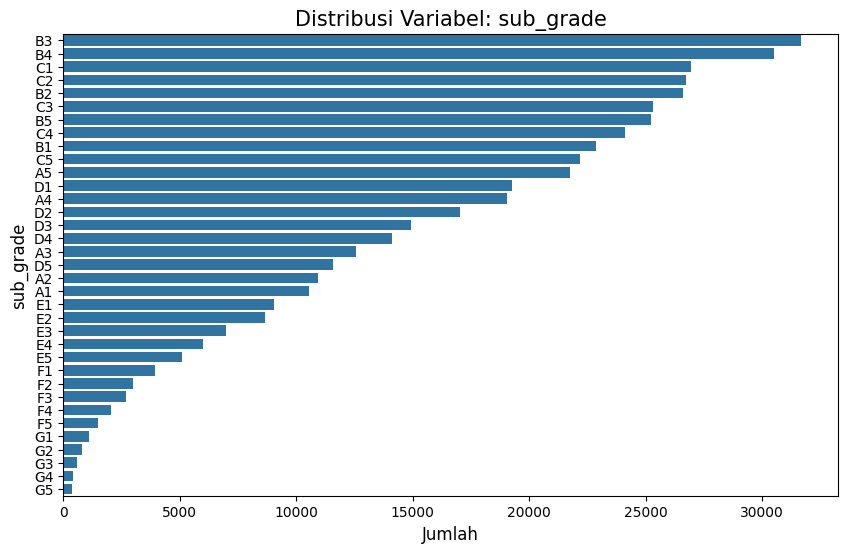

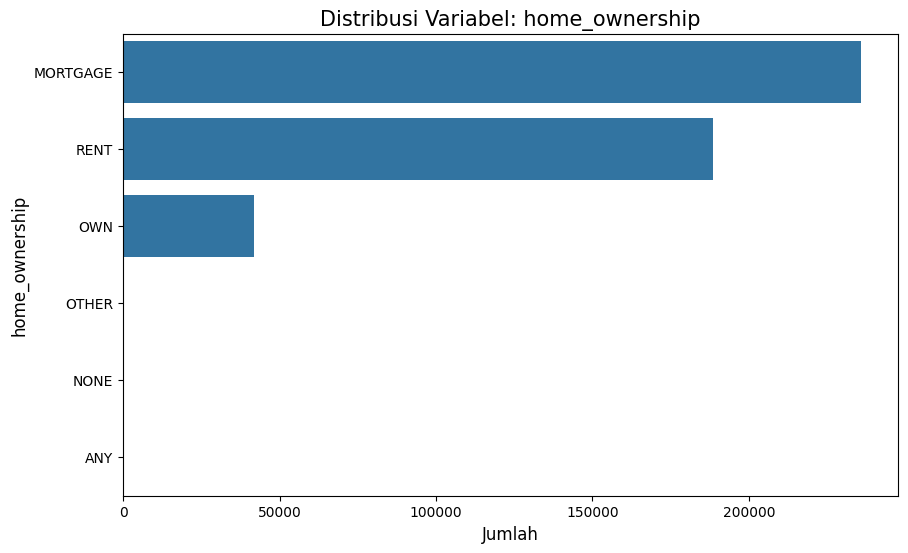

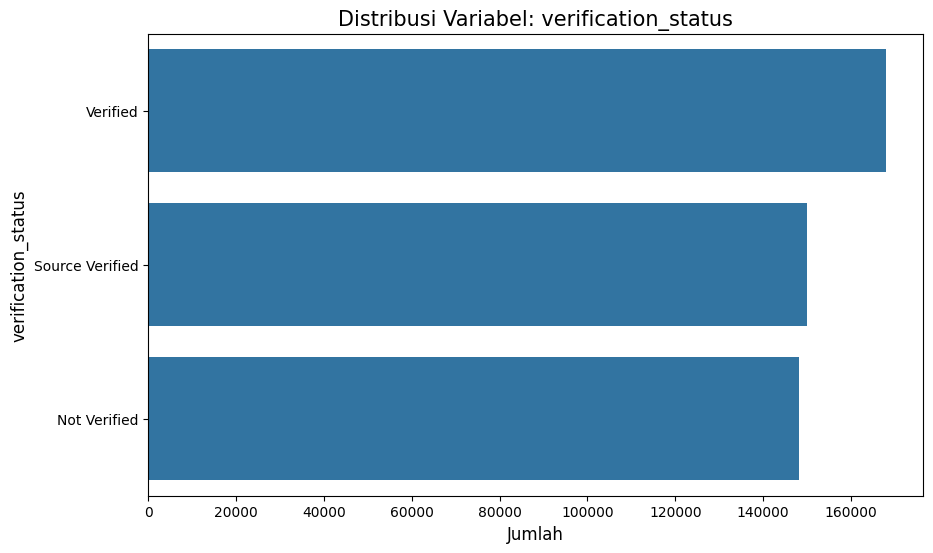

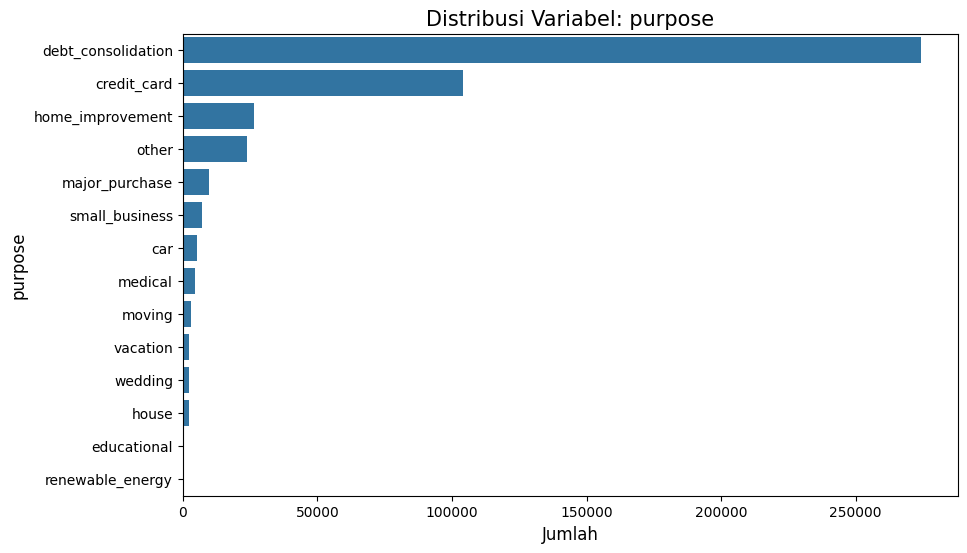

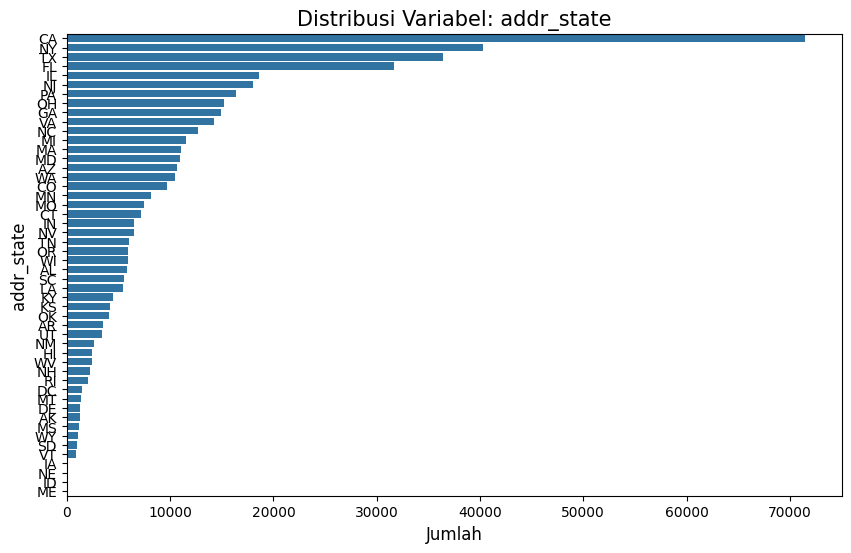

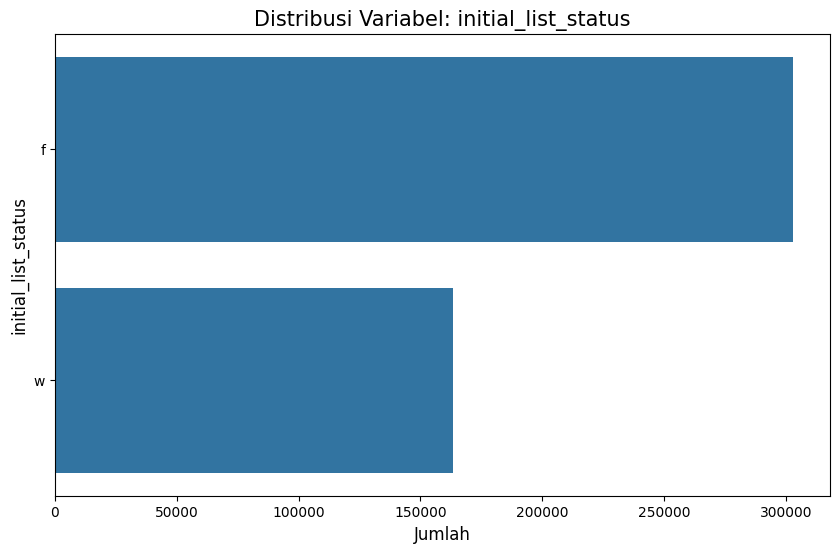

In [41]:
for column in cat_var:
    plt.figure(figsize=(10, 6))

    sns.countplot(data=df, y=column, order=df[column].value_counts().index)

    plt.title(f'Distribusi Variabel: {column}', fontsize=15)
    plt.xlabel('Jumlah', fontsize=12)
    plt.ylabel(column, fontsize=12)
    plt.show()

### Numerical data

In [42]:
num_var = df.select_dtypes(exclude='object').columns
num_var

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'bad_flag', 'emp_length_int',
       'term_int', 'mths_since_earliest_cr_line', 'mths_since_issue_d',
       'credit_utilization', 'installment_income_ratio', 'loan_income_ratio',
       'avg_credit_per_account', 'revol_bal_per_open_acc'],
      dtype='object')

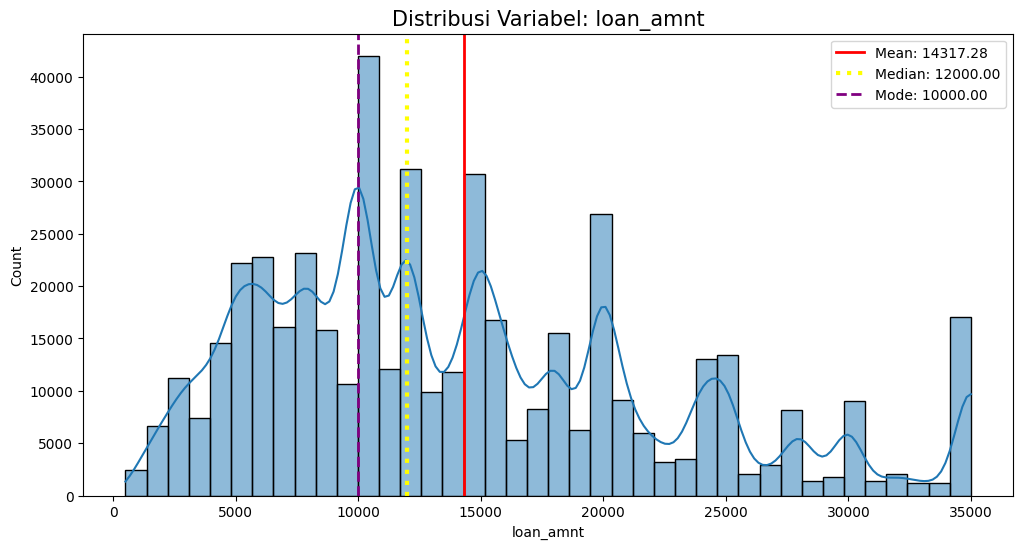

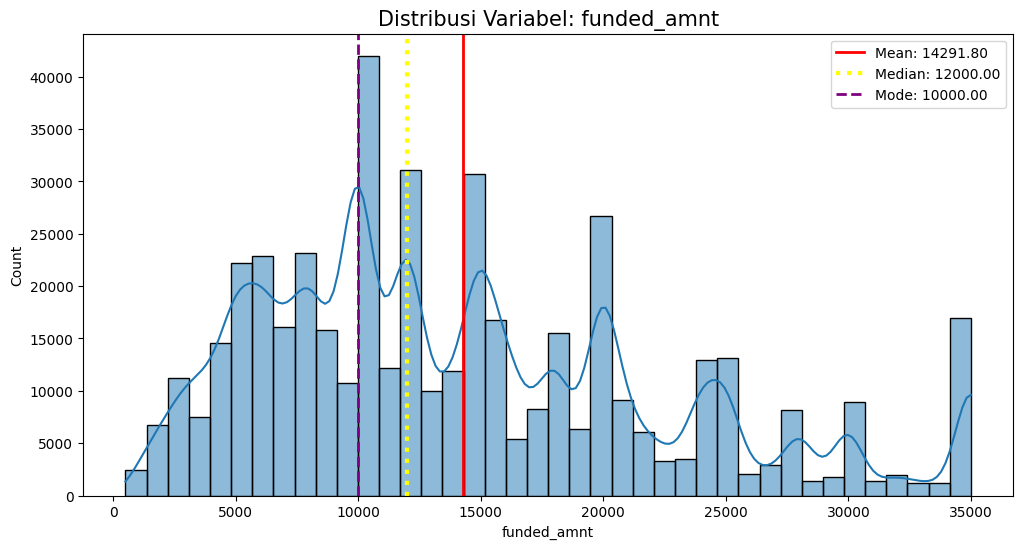

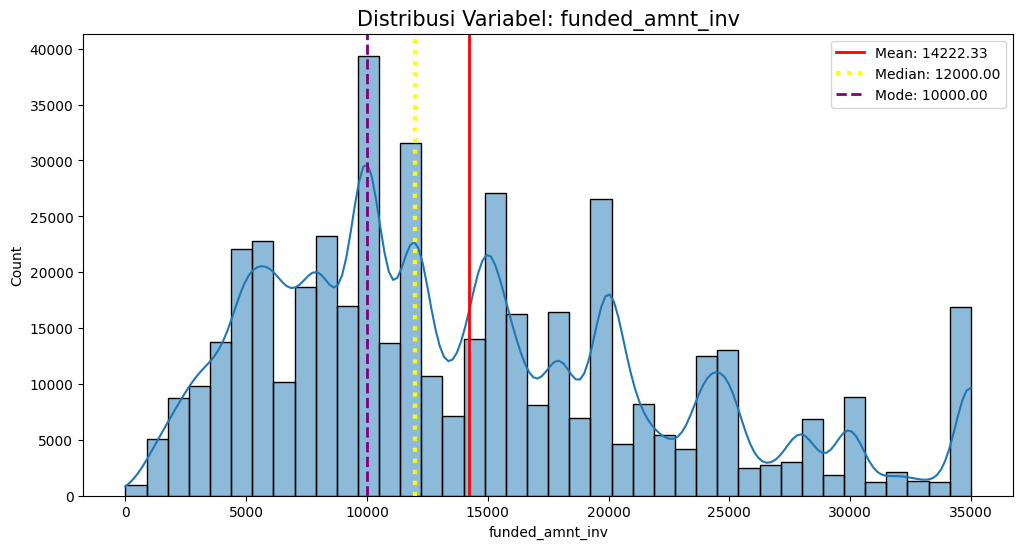

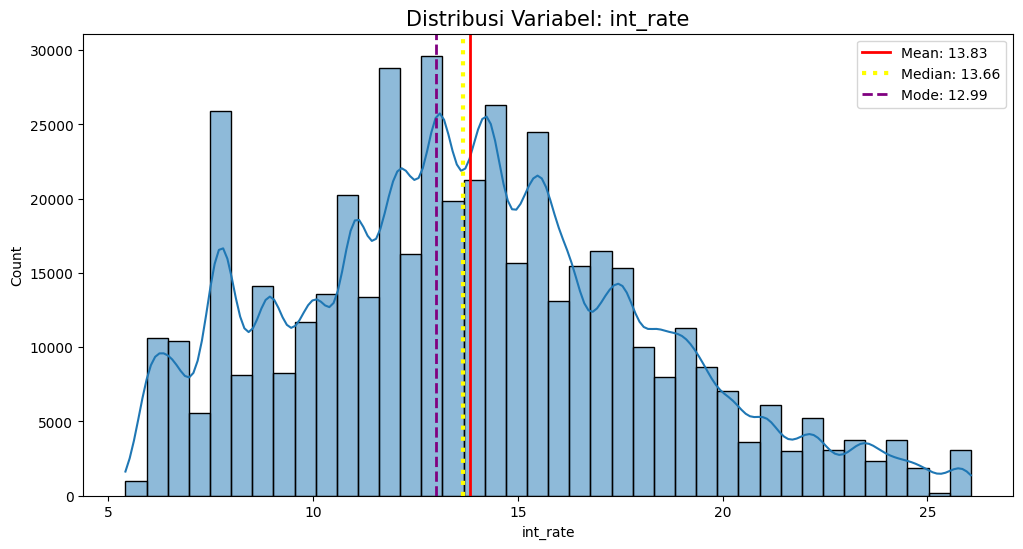

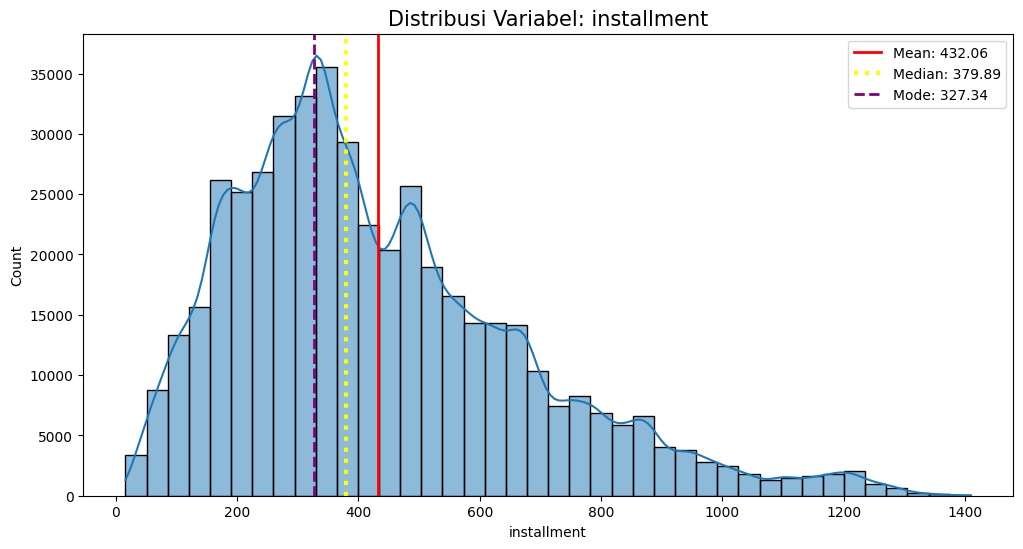

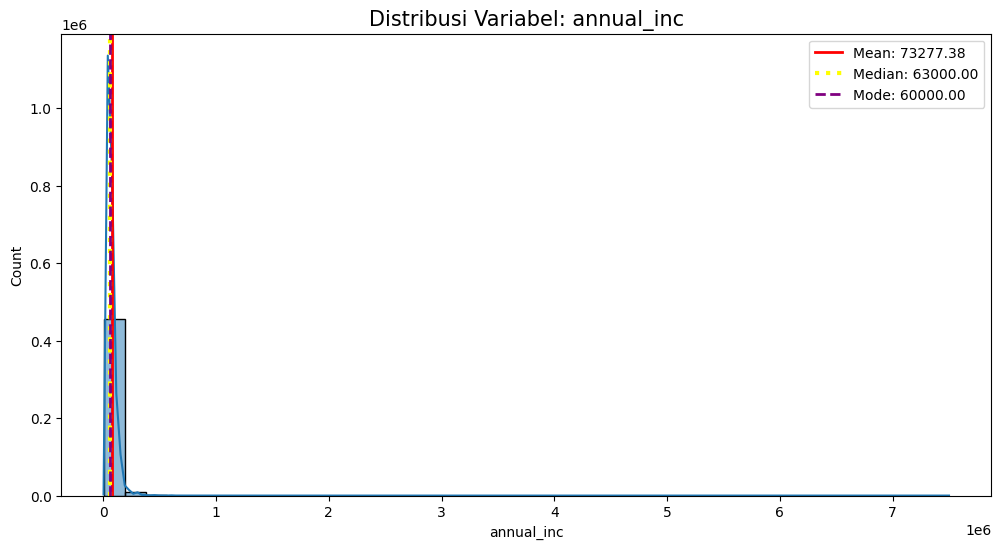

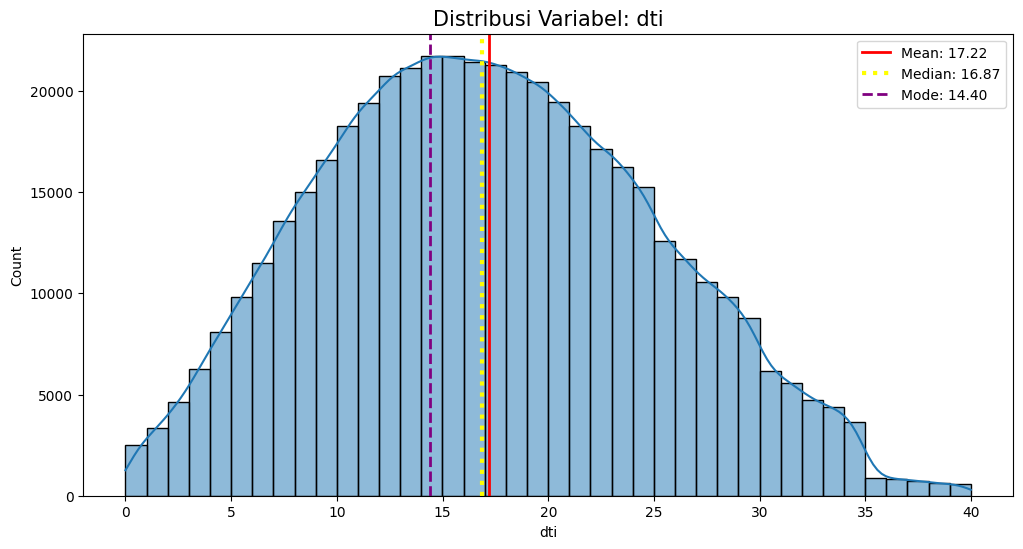

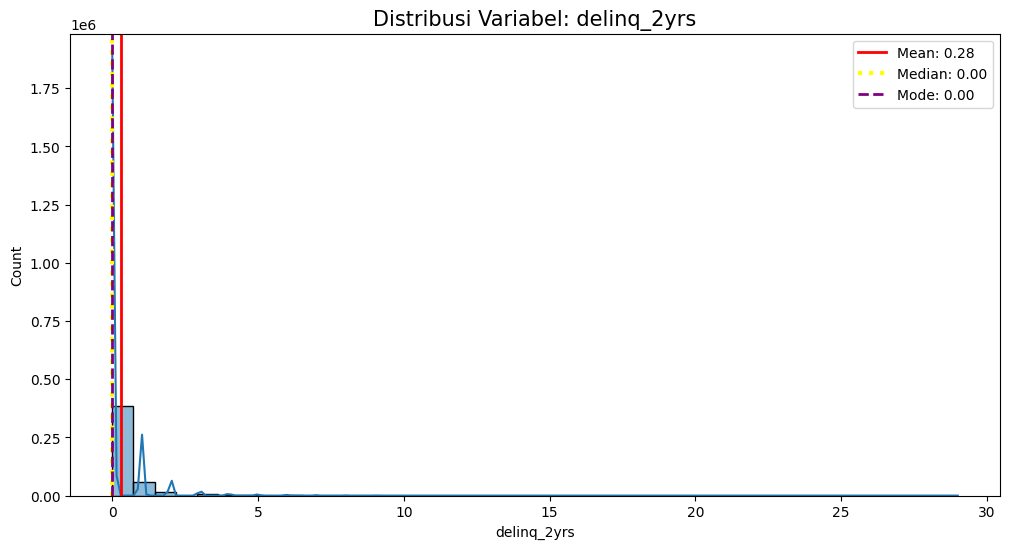

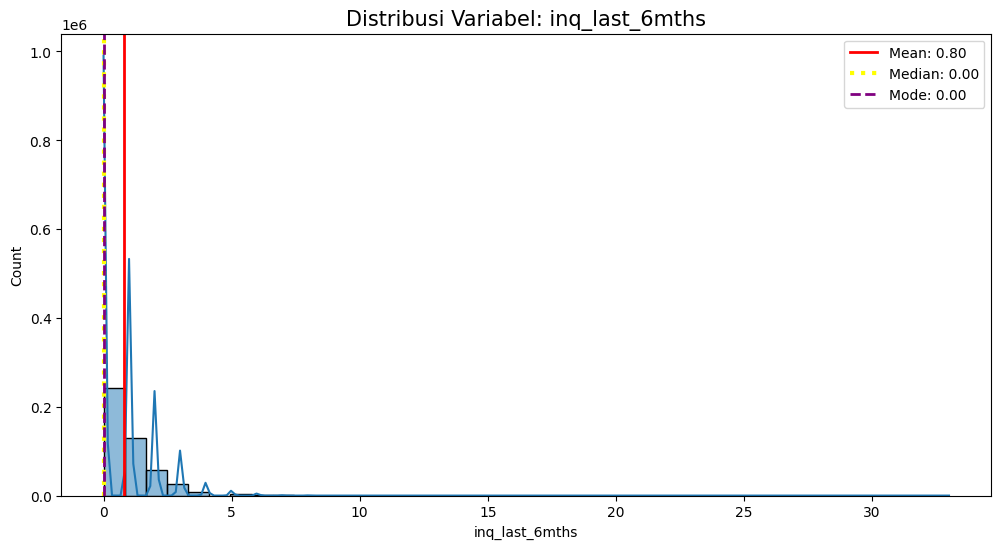

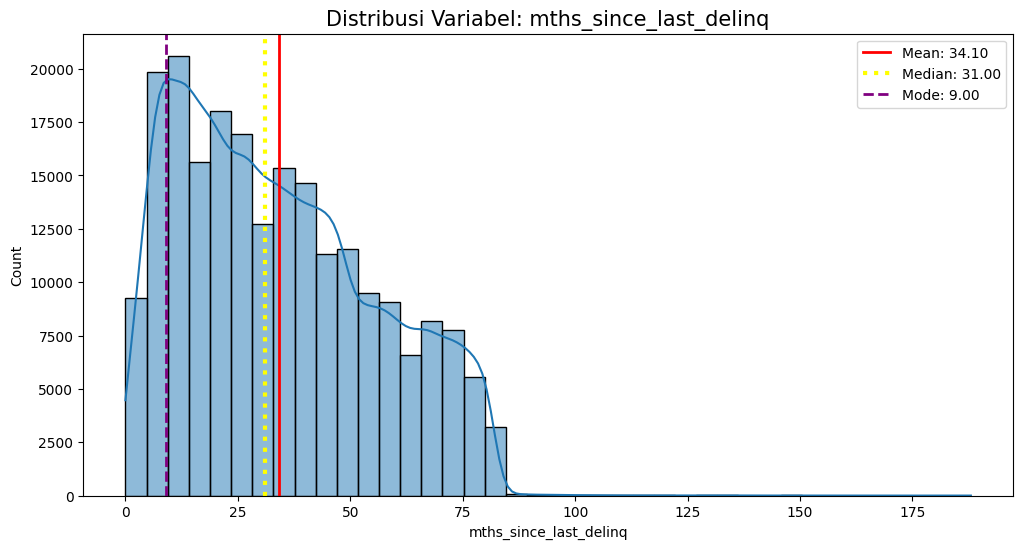

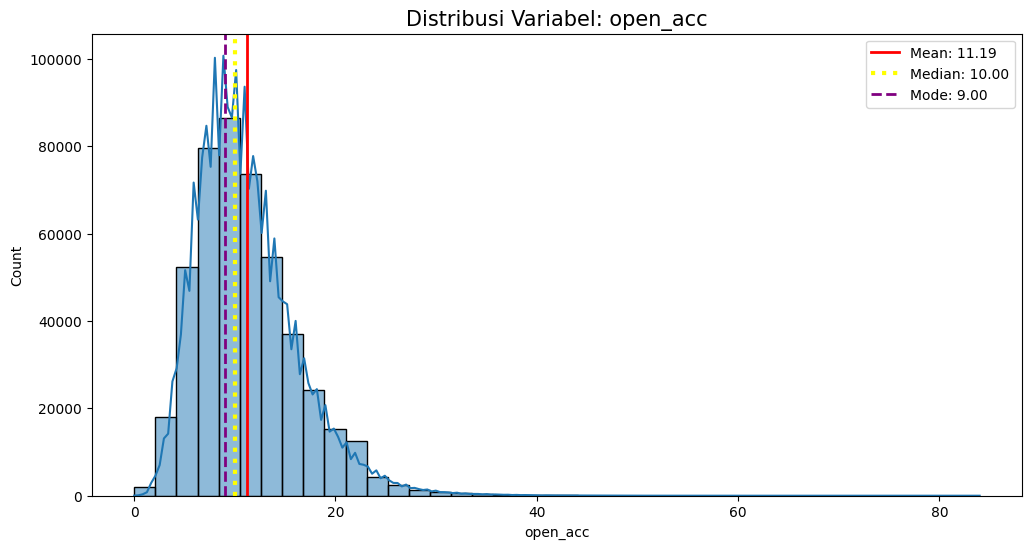

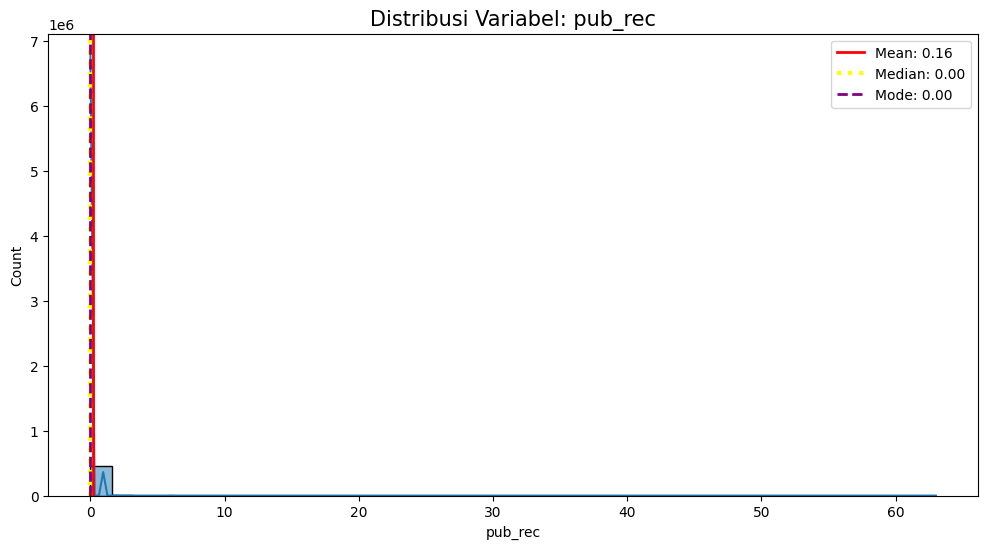

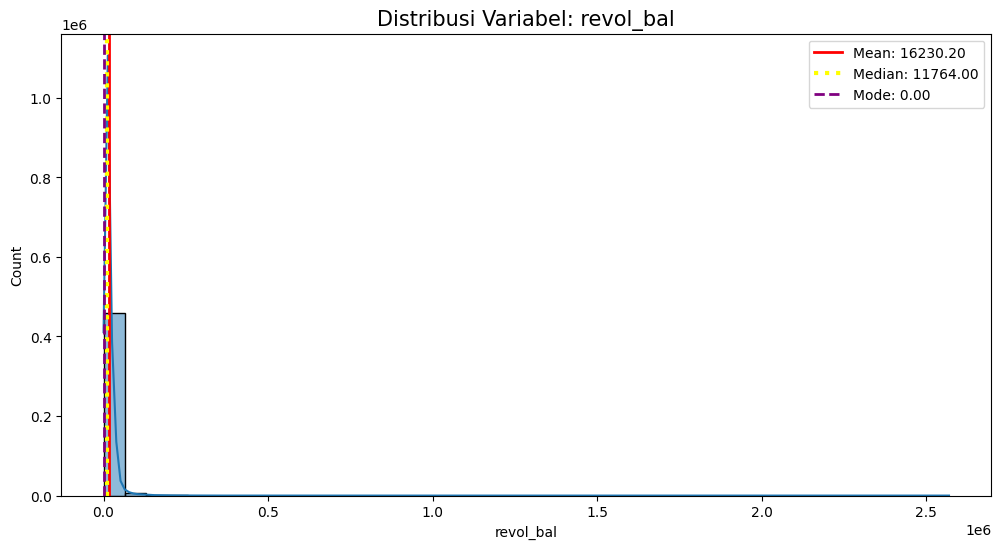

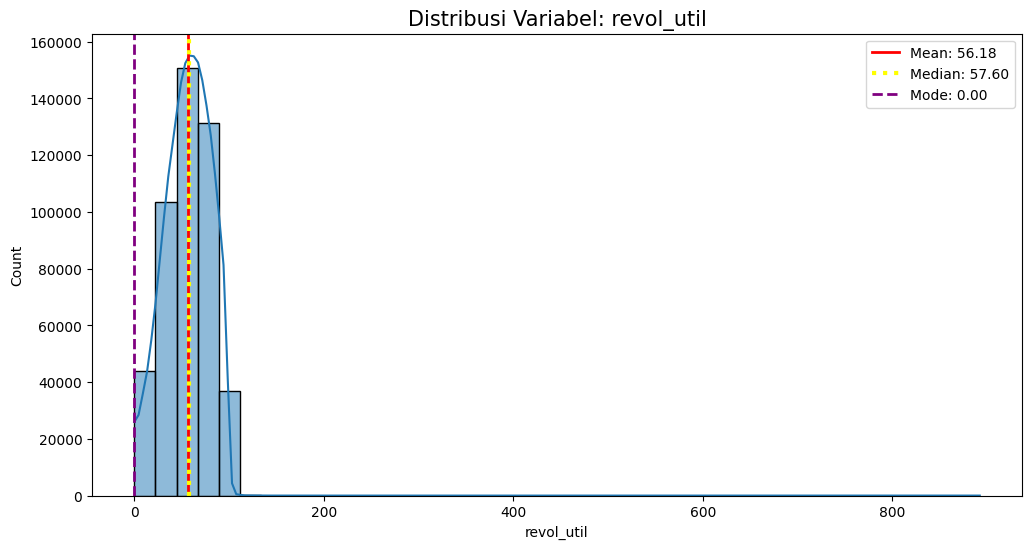

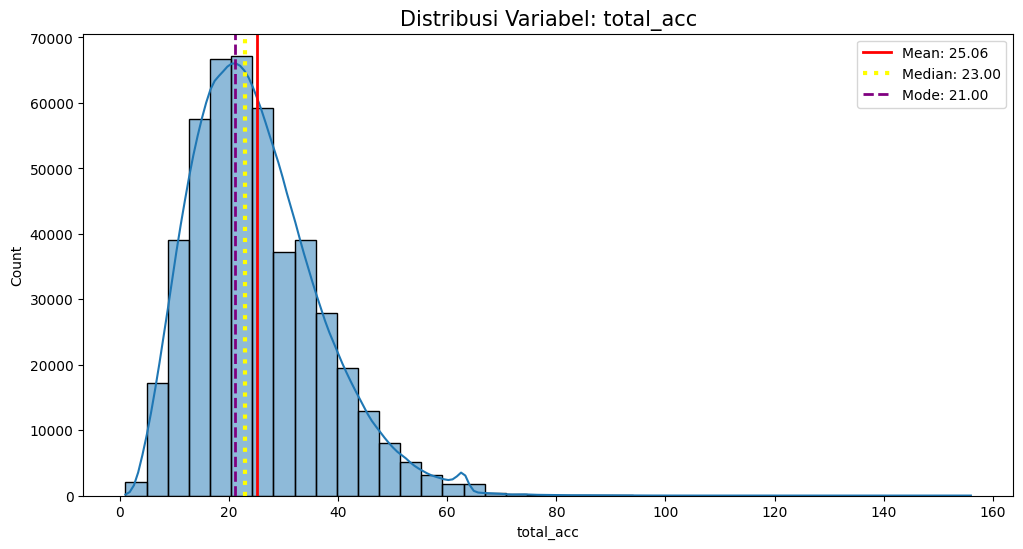

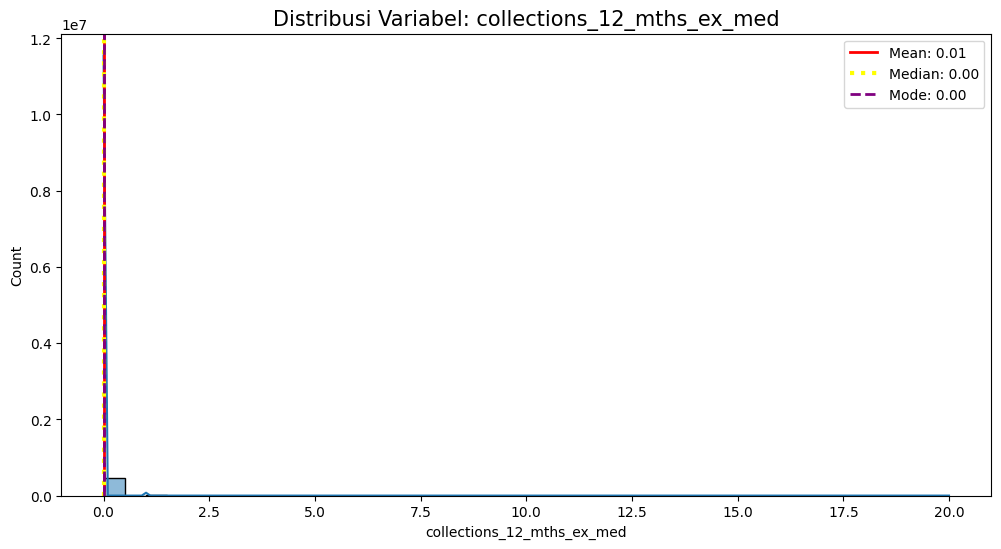

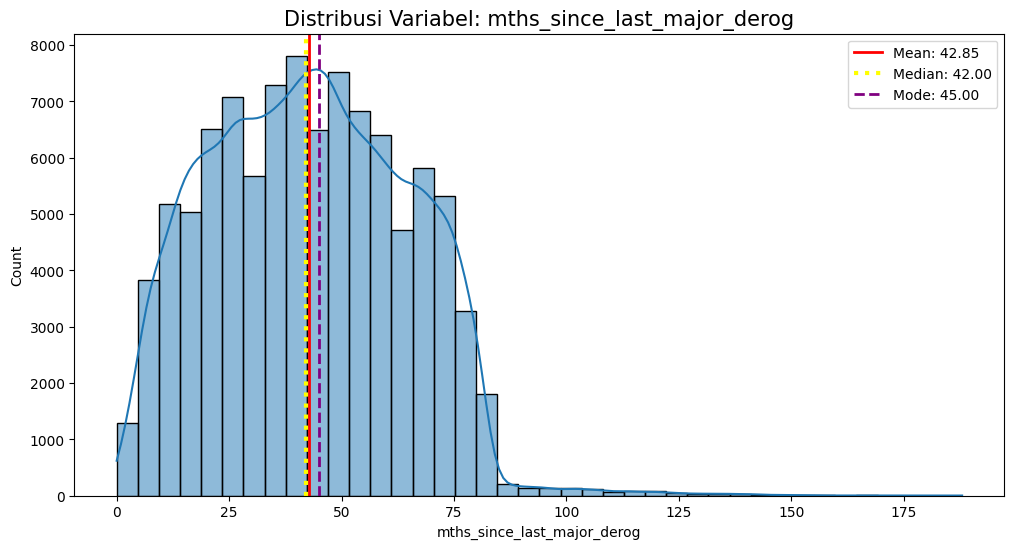

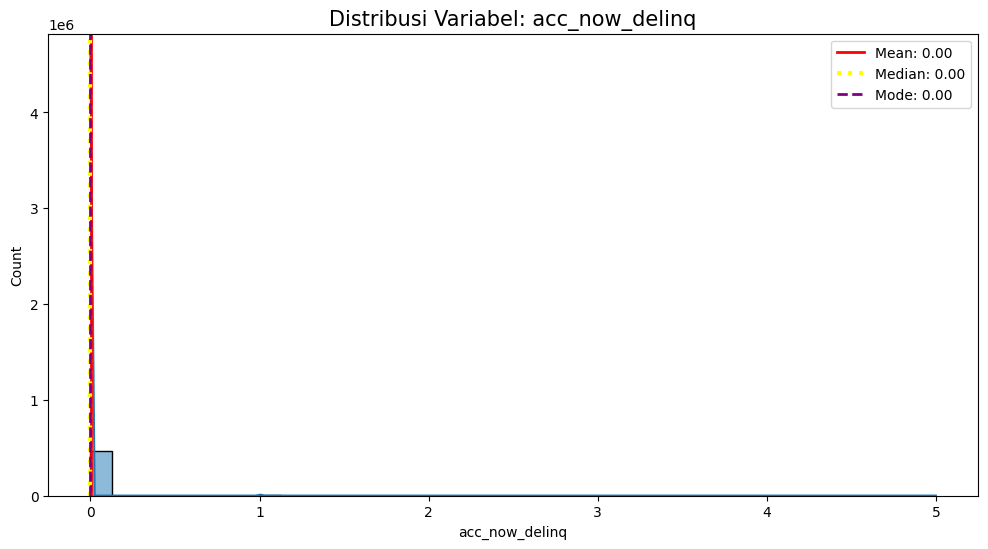

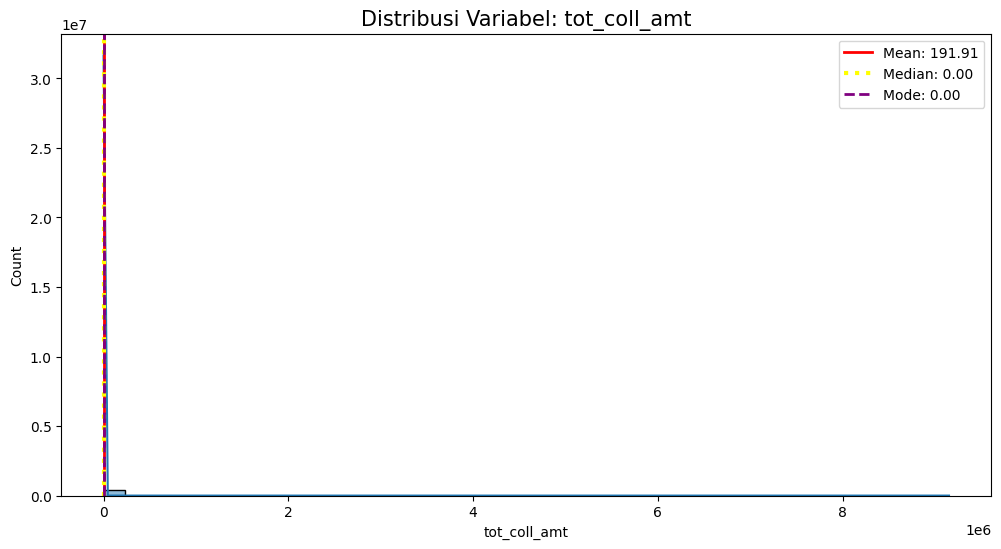

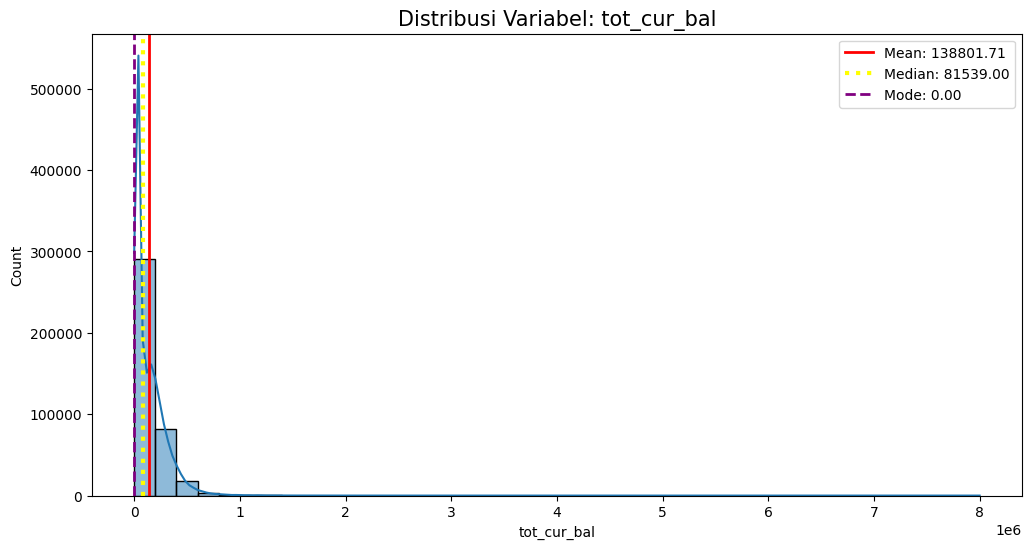

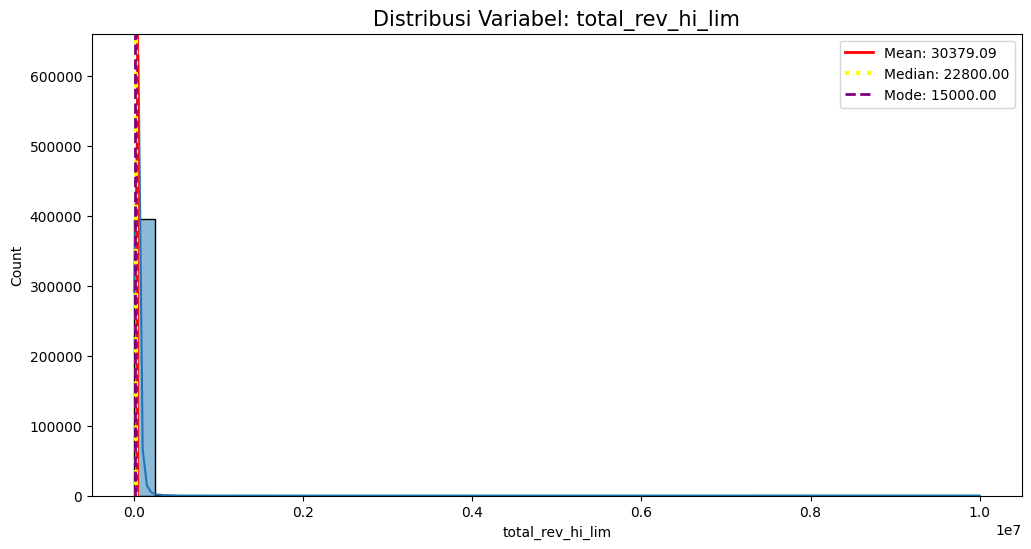

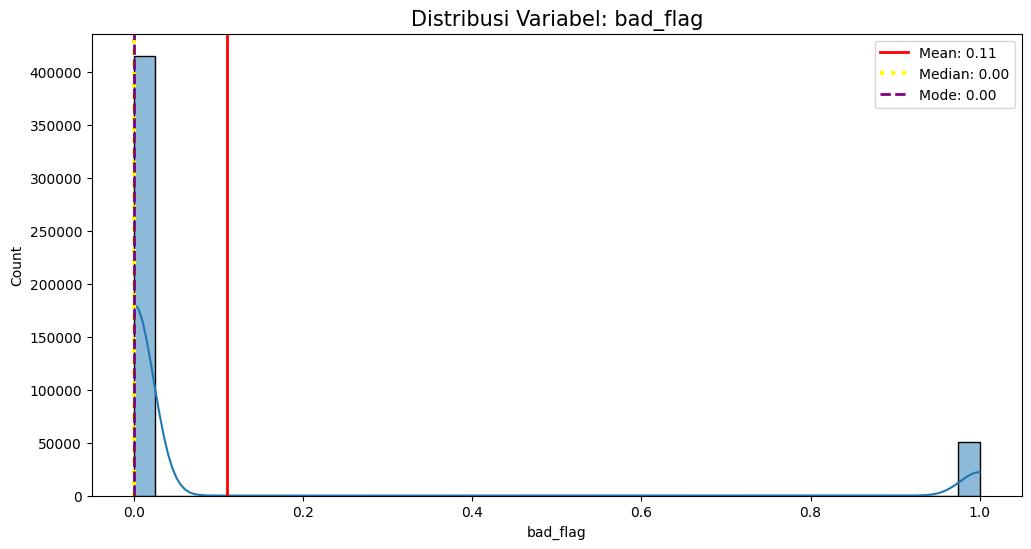

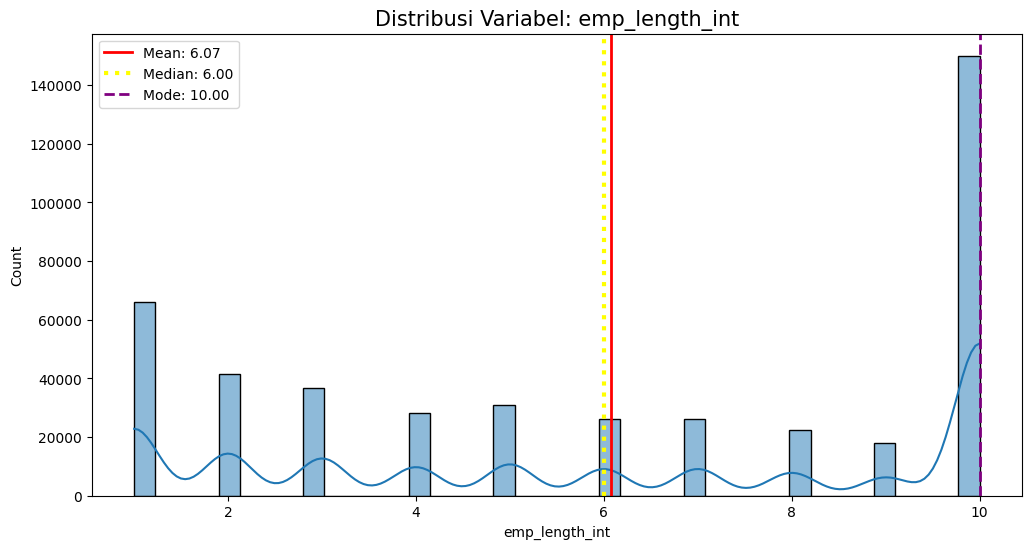

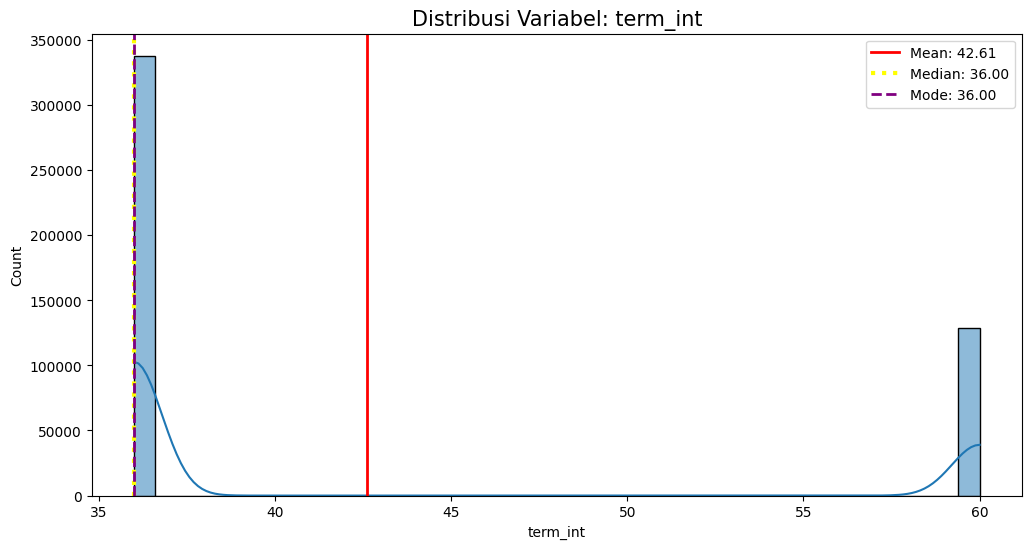

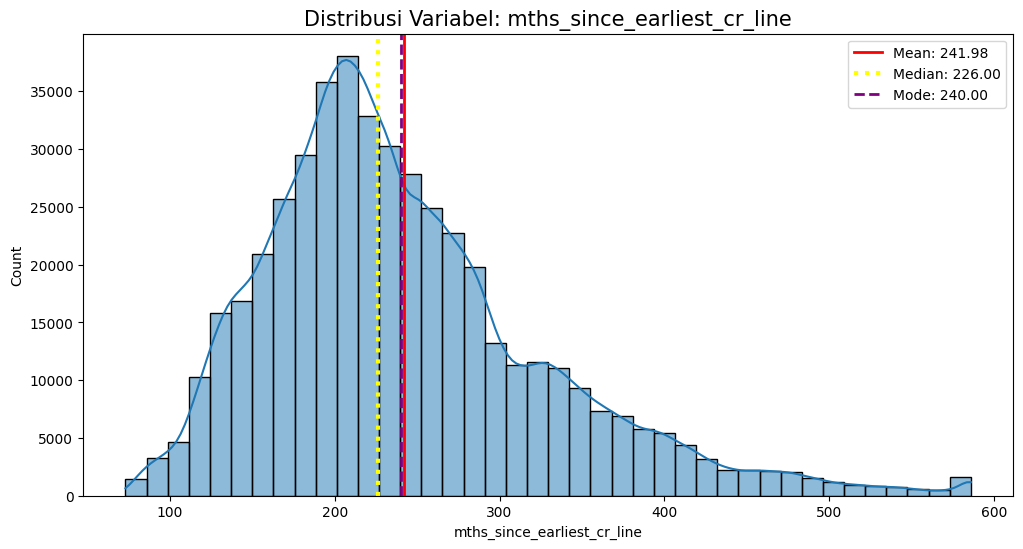

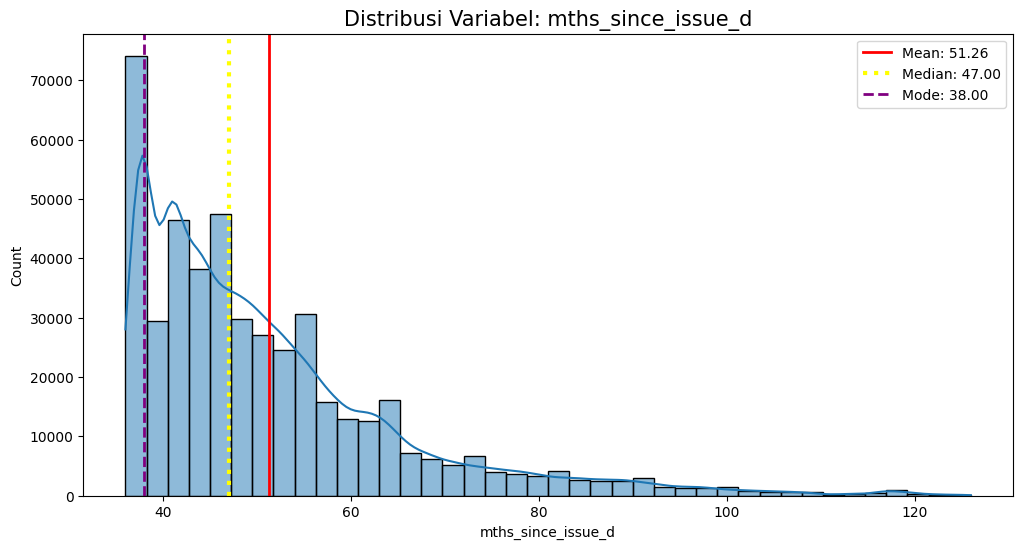

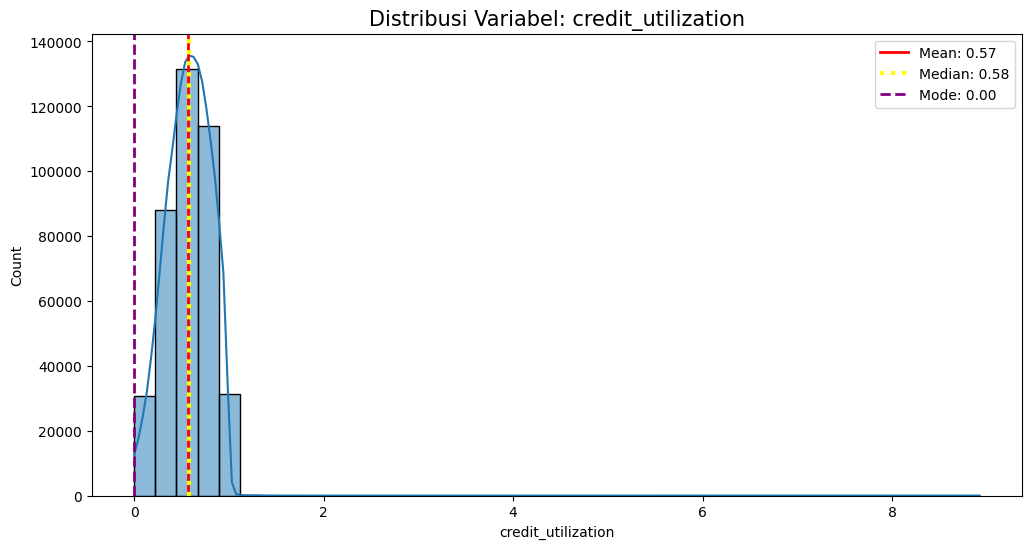

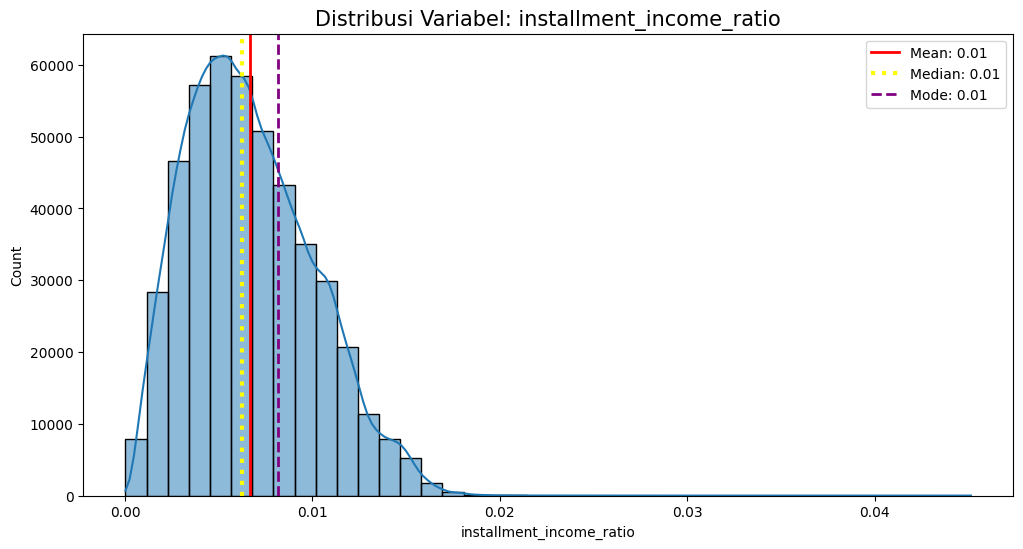

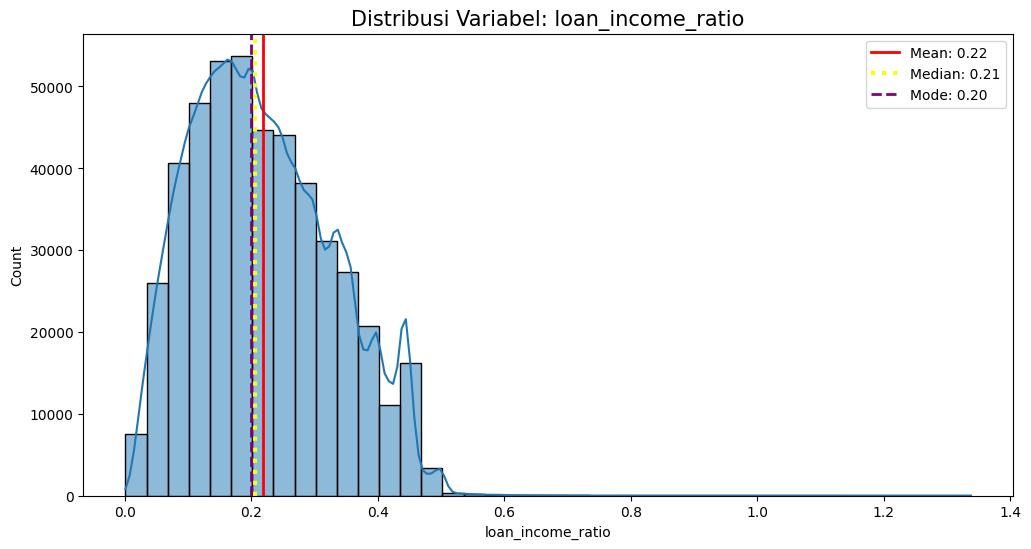

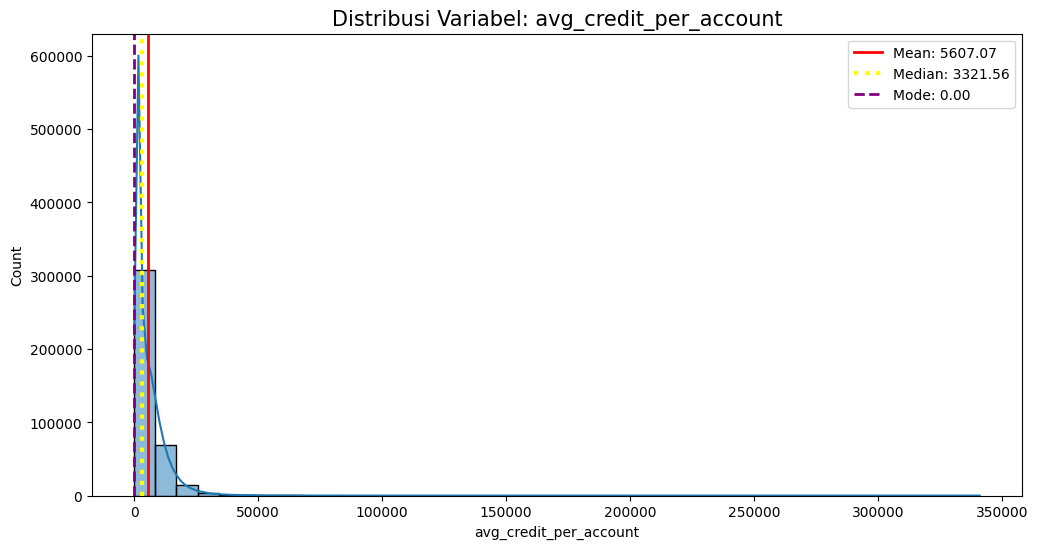

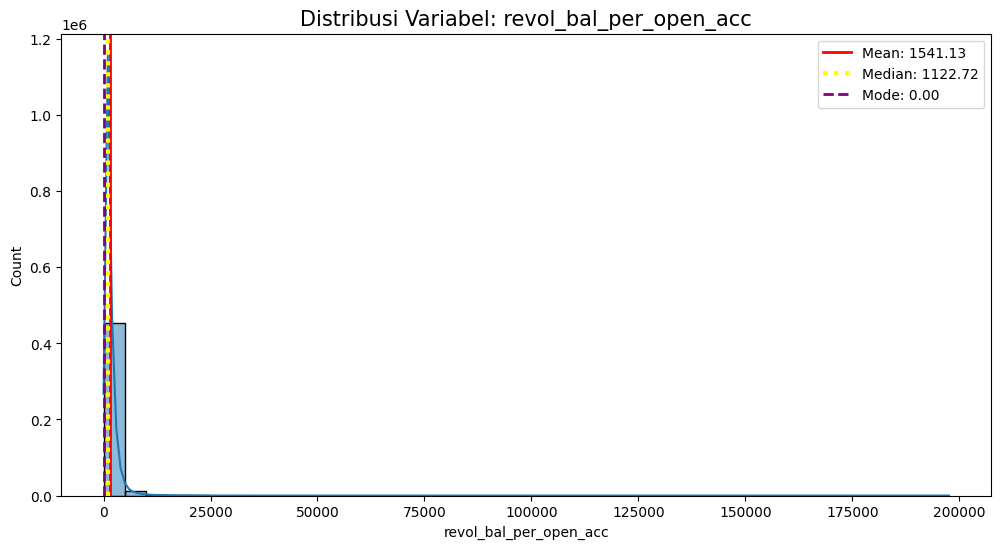

In [43]:
for column in num_var:
    mean_val = df[column].mean()
    median_val = df[column].median()
    mode_val = df[column].mode().values[0]

    plt.figure(figsize=(12, 6))
    sns.histplot(df[column], kde=True, bins=40)

    plt.axvline(mean_val, color='red', linestyle='solid', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='yellow', linestyle='dotted', linewidth=3, label=f'Median: {median_val:.2f}')
    plt.axvline(mode_val, color='purple', linestyle='dashed', linewidth=2, label=f'Mode: {mode_val:.2f}')

    plt.title(f'Distribusi Variabel: {column}', fontsize=15)
    plt.legend()
    plt.show()

## 5.2 Bivariate Analysis

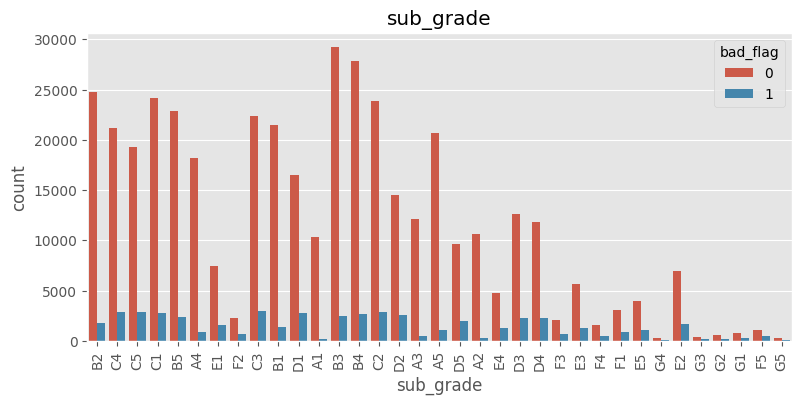

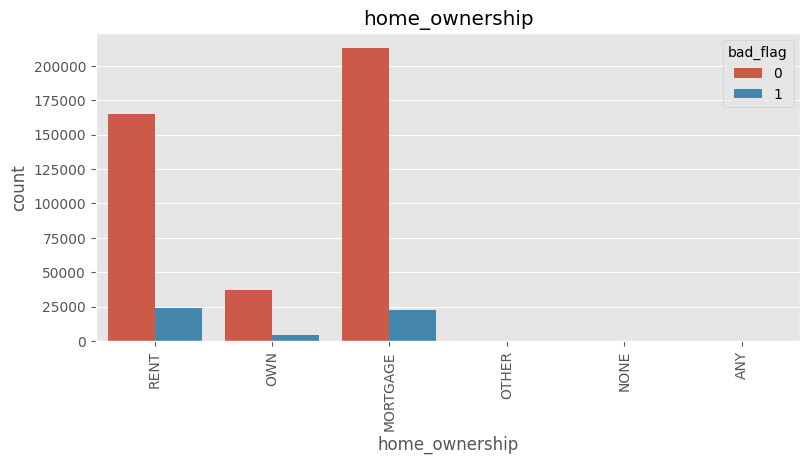

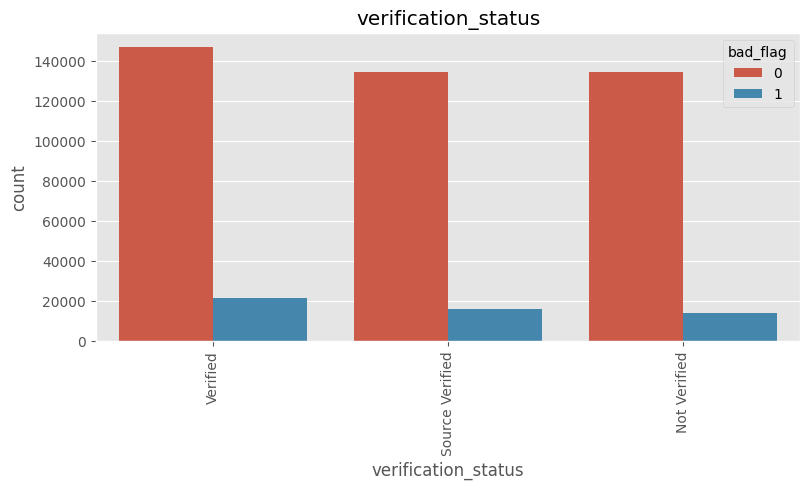

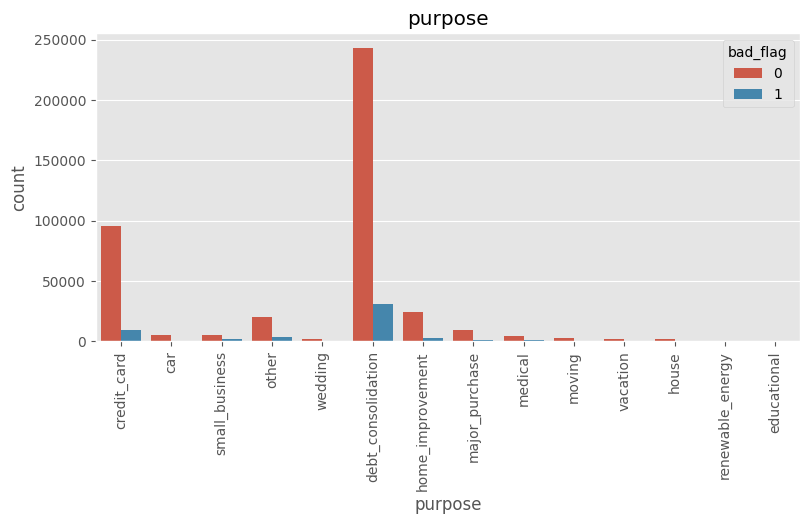

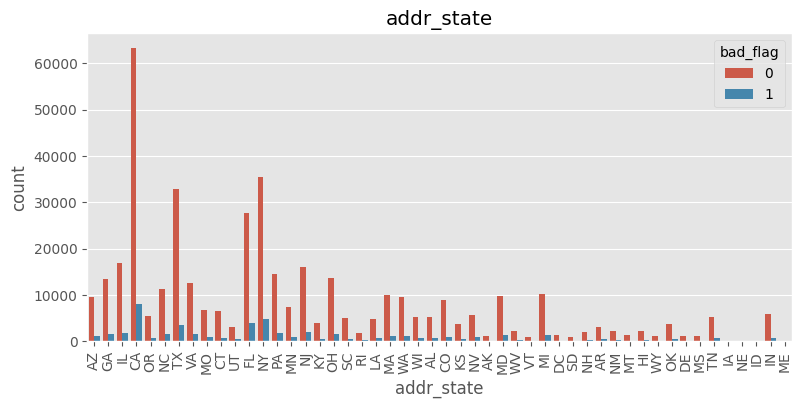

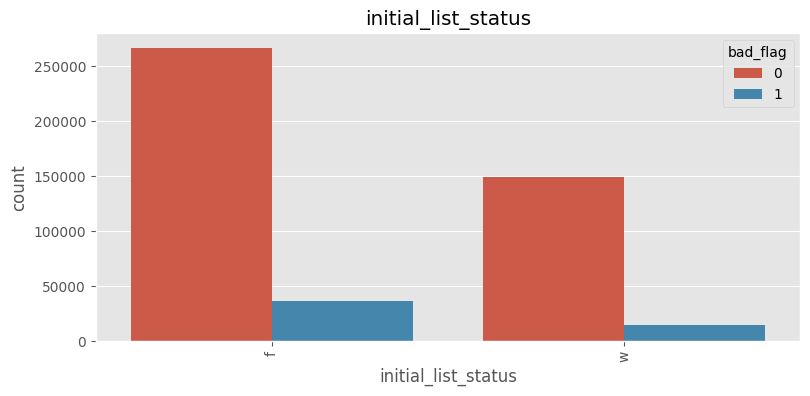

In [44]:
plt.style.use("ggplot")
for column in cat_var:
    plt.figure(figsize=(20, 4))
    plt.subplot(121)
    sns.countplot(x=df[column], hue=df["bad_flag"])
    plt.title(column)
    plt.xticks(rotation=90)

# 6. Data Preprocessing

## 6.1 Imputation

In [45]:
df.isnull().sum()

,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
int_rate,0
installment,0
sub_grade,0
home_ownership,0
annual_inc,4
verification_status,0
purpose,0


In [46]:
check_missing = df.isnull().sum() * 100 / df.shape[0]
missing_values = check_missing[check_missing > 0].sort_values(ascending=False)
print(missing_values)

mths_since_last_major_derog    78.773926
mths_since_last_delinq         53.690554
credit_utilization             15.104711
tot_coll_amt                   15.071469
tot_cur_bal                    15.071469
total_rev_hi_lim               15.071469
avg_credit_per_account         15.071469
emp_length_int                  4.505399
revol_util                      0.072917
collections_12_mths_ex_med      0.031097
revol_bal_per_open_acc          0.007721
delinq_2yrs                     0.006219
inq_last_6mths                  0.006219
acc_now_delinq                  0.006219
open_acc                        0.006219
pub_rec                         0.006219
total_acc                       0.006219
mths_since_earliest_cr_line     0.006219
annual_inc                      0.000858
loan_income_ratio               0.000858
installment_income_ratio        0.000858
dtype: float64


In [47]:
df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)
df['mths_since_earliest_cr_line'].fillna(df['mths_since_earliest_cr_line'].median(), inplace=True)
df['acc_now_delinq'].fillna(0, inplace=True)
df['pub_rec'].fillna(0, inplace=True)
df['inq_last_6mths'].fillna(0, inplace=True)
df['delinq_2yrs'].fillna(0, inplace=True)
df['collections_12_mths_ex_med'].fillna(0, inplace=True)
df['total_acc'].fillna(df['total_acc'].median(), inplace=True)
df['open_acc'].fillna(df['open_acc'].median(), inplace=True)
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)
df['emp_length_int'].fillna(0, inplace=True)
df['mths_since_last_delinq'].fillna(-1, inplace=True)
df['mths_since_last_major_derog'].fillna(-1, inplace=True)
df['sub_grade'].fillna('N/A', inplace=True)
df['home_ownership'].fillna('UNKNOWN', inplace=True)
df['verification_status'].fillna('UNKNOWN', inplace=True)
df['purpose'].fillna('UNKNOWN', inplace=True)
df['addr_state'].fillna('UNKNOWN', inplace=True)
df['dti'].fillna(df['dti'].median(), inplace=True)
df['term_int'].fillna(df['term_int'].mode()[0], inplace=True)
df['mths_since_issue_d'].fillna(df['mths_since_issue_d'].median(), inplace=True)
df['tot_coll_amt'].fillna(0, inplace=True)
df['tot_cur_bal'].fillna(df['tot_cur_bal'].median(), inplace=True)
df['total_rev_hi_lim'].fillna(df['total_rev_hi_lim'].median(), inplace=True)
df['credit_utilization'].fillna(df['credit_utilization'].median(), inplace=True)
df['loan_income_ratio'].fillna(df['loan_income_ratio'].median(), inplace=True)
df['installment_income_ratio'].fillna(df['installment_income_ratio'].median(), inplace=True)
df['avg_credit_per_account'].fillna(df['avg_credit_per_account'].median(), inplace=True)
df['revol_bal_per_open_acc'].fillna(df['revol_bal_per_open_acc'].median(), inplace=True)

## 6.2 Ordinal Mapping

In [48]:
sub_grade_mapping = {
    'N/A': 0,
    'A1': 1, 'A2': 2, 'A3': 3, 'A4': 4, 'A5': 5,
    'B1': 6, 'B2': 7, 'B3': 8, 'B4': 9, 'B5': 10,
    'C1': 11, 'C2': 12, 'C3': 13, 'C4': 14, 'C5': 15,
    'D1': 16, 'D2': 17, 'D3': 18, 'D4': 19, 'D5': 20,
    'E1': 21, 'E2': 22, 'E3': 23, 'E4': 24, 'E5': 25,
    'F1': 26, 'F2': 27, 'F3': 28, 'F4': 29, 'F5': 30,
    'G1': 31, 'G2': 32, 'G3': 33, 'G4': 34, 'G5': 35
}

df['sub_grade'] = df['sub_grade'].map(sub_grade_mapping)

## 6.3 Label Encoding

In [49]:
label = LabelEncoder()

cat_var = [col for col in cat_var if col != 'sub_grade']

for column in cat_var:
    df[column] = label.fit_transform(df[column])

## 6.4 Train-Validation Split

In [50]:
X = df.drop('bad_flag', axis=1)
y = df['bad_flag']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train Shape :", X_train.shape)
print("Validation Shape :", X_val.shape)

Train Shape : (373028, 36)
Validation Shape : (93257, 36)


## 6.5 Target Distribution Check

In [51]:
distribution_df = pd.DataFrame({
    "Train Count": y_train.value_counts(),
    "Train (%)": (
        y_train.value_counts(normalize=True) * 100
    ).round(2),
    "Validation Count": y_val.value_counts(),
    "Validation (%)": (
        y_val.value_counts(normalize=True) * 100
    ).round(2)
})

distribution_df.index.name = "Bad Flag"

display(distribution_df)

,Train Count,Train (%),Validation Count,Validation (%)
Bad Flag,,,,
0,332254,89.07,83063,89.07
1,40774,10.93,10194,10.93


## 6.6 Feature Scaling

In [52]:
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_val[numeric_features] = scaler.transform(
    X_val[numeric_features]
)

print("Feature scaling completed.")
print("Number of numeric features:", len(numeric_features))

Feature scaling completed.
Number of numeric features: 36


# 7. Modelling

In [53]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = {
    'auc': 'roc_auc',
    'log_loss': make_scorer(
        log_loss,
        response_method='predict_proba',
        greater_is_better=False
    )
}

## 7.1 Logistic Regression

In [54]:
logreg_pipeline = ImbPipeline([
    (
        'model',
        LogisticRegression(
            random_state=42,
            solver='saga',
            class_weight='balanced',
            max_iter=1000
        )
    )
])

logreg_params = {
    'model__C': [0.01, 0.1, 1.0],
    'model__penalty': ['l1', 'l2']
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_params,
    n_iter=4,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

logreg_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(logreg_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters:
{'model__penalty': 'l2', 'model__C': 0.01}


## 7.2 Random Forest

In [55]:
rf_pipeline = ImbPipeline([
    (
        'model',
        RandomForestClassifier(
            random_state=42,
            criterion='gini',
            class_weight='balanced',
            oob_score=True,
            n_jobs=-1
        )
    )
])

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=6,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(rf_search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 10}


## 7.3 LightGBM

In [56]:
lgbm_pipeline = ImbPipeline([
    (
        'model',
        LGBMClassifier(
            random_state=42,
            objective='binary',
            class_weight='balanced',
            importance_type='gain',
            verbose=-1,
            n_jobs=-1
        )
    )
])

lgbm_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 63],
    'model__max_depth': [-1, 10]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_params,
    n_iter=6,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(lgbm_search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'model__num_leaves': 63, 'model__n_estimators': 100, 'model__max_depth': -1, 'model__learning_rate': 0.05}


# 8. Evaluation

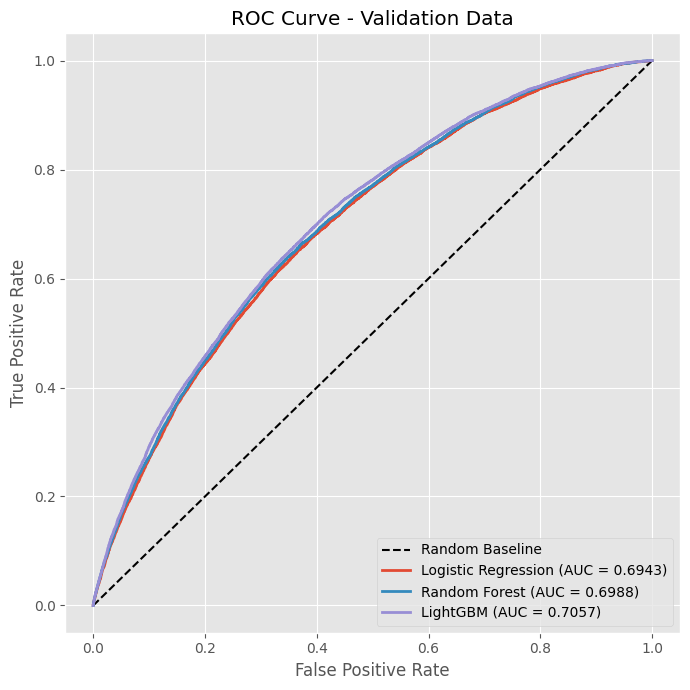

,ROC-AUC,Log Loss
LightGBM,0.7057,0.6157
Random Forest,0.6988,0.6010
Logistic Regression,0.6943,0.6332


In [57]:
def evaluate_model(model, X, y):

    y_prob = model.predict_proba(X)[:, 1]

    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    fpr, tpr, _ = roc_curve(y, y_prob)

    return auc, loss, fpr, tpr


fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Baseline"
)

results = {}

models = [
    ("Logistic Regression", logreg_search.best_estimator_),
    ("Random Forest", rf_search.best_estimator_),
    ("LightGBM", lgbm_search.best_estimator_)
]

for name, model in models:

    auc, loss, fpr, tpr = evaluate_model(
        model=model,
        X=X_val,
        y=y_val
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.4f})"
    )

    results[name] = {
        "ROC-AUC": auc,
        "Log Loss": loss
    }

ax.set_title("ROC Curve - Validation Data")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

comparison_df = (
    pd.DataFrame(results)
    .T
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
    .round(4)
)

display(comparison_df)

# 9. Feature Importance

## 9.1 Logistic Regression

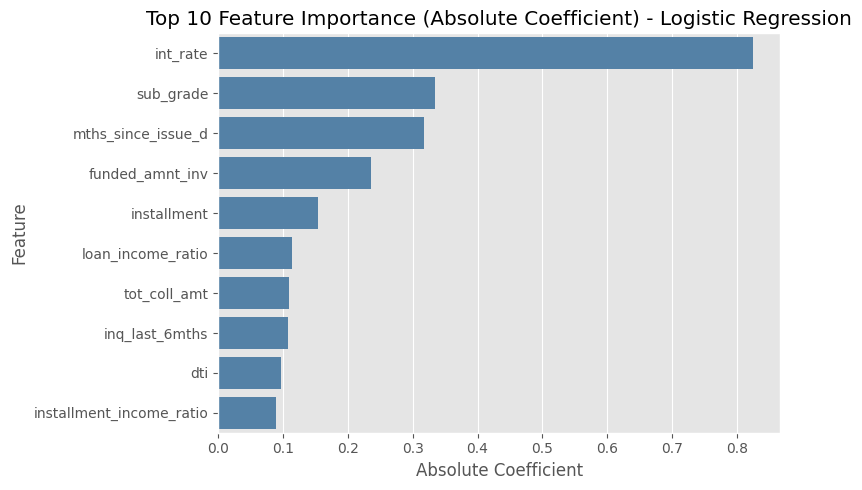

Top 10 Feature Importance (Absolute Coefficient) - Logistic Regression


,Feature,Absolute Coefficient
3,int_rate,0.825222
5,sub_grade,0.334817
30,mths_since_issue_d,0.317693
2,funded_amnt_inv,0.235568
4,installment,0.154313
33,loan_income_ratio,0.113202
24,tot_coll_amt,0.108533
13,inq_last_6mths,0.108045
11,dti,0.097252
32,installment_income_ratio,0.089854


In [58]:
best_logreg = logreg_search.best_estimator_.named_steps["model"]

coef_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Absolute Coefficient": np.abs(best_logreg.coef_[0])
    })
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
)

top10_coef = coef_df.head(10)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top10_coef,
    x="Absolute Coefficient",
    y="Feature",
    color="steelblue",
    ax=ax
)

ax.set_title("Top 10 Feature Importance (Absolute Coefficient) - Logistic Regression")
ax.set_xlabel("Absolute Coefficient")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

print("Top 10 Feature Importance (Absolute Coefficient) - Logistic Regression")

display(top10_coef)

## 9.2 Random Forest

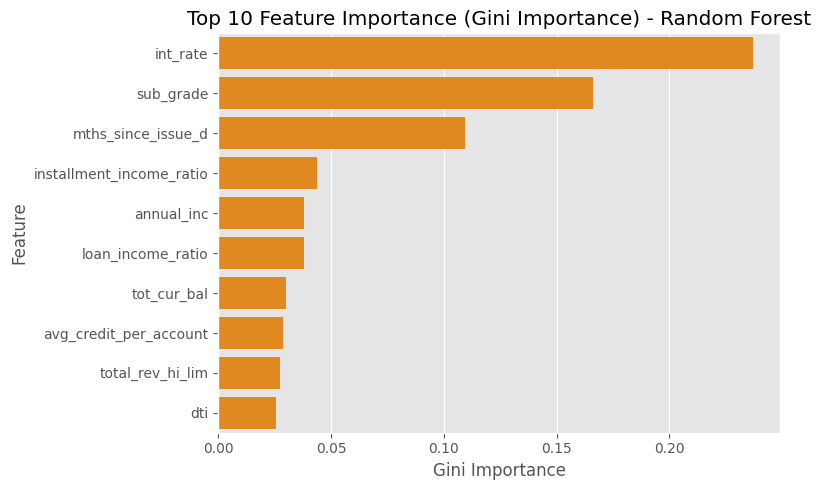

Top 10 Feature Importance (Gini Importance) - Random Forest


,Feature,Gini Importance
3,int_rate,0.237191
5,sub_grade,0.166193
30,mths_since_issue_d,0.109308
32,installment_income_ratio,0.043955
7,annual_inc,0.038263
33,loan_income_ratio,0.037947
25,tot_cur_bal,0.030194
34,avg_credit_per_account,0.028862
26,total_rev_hi_lim,0.027276
11,dti,0.025478


In [59]:
best_rf = rf_search.best_estimator_.named_steps["model"]

rf_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Gini Importance": best_rf.feature_importances_
    })
    .sort_values(
        "Gini Importance",
        ascending=False
    )
)

top10_rf = rf_importance.head(10)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top10_rf,
    x="Gini Importance",
    y="Feature",
    color="darkorange",
    ax=ax
)

ax.set_title("Top 10 Feature Importance (Gini Importance) - Random Forest")
ax.set_xlabel("Gini Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

print("Top 10 Feature Importance (Gini Importance) - Random Forest")

display(top10_rf)

## 9.3 LightGBM

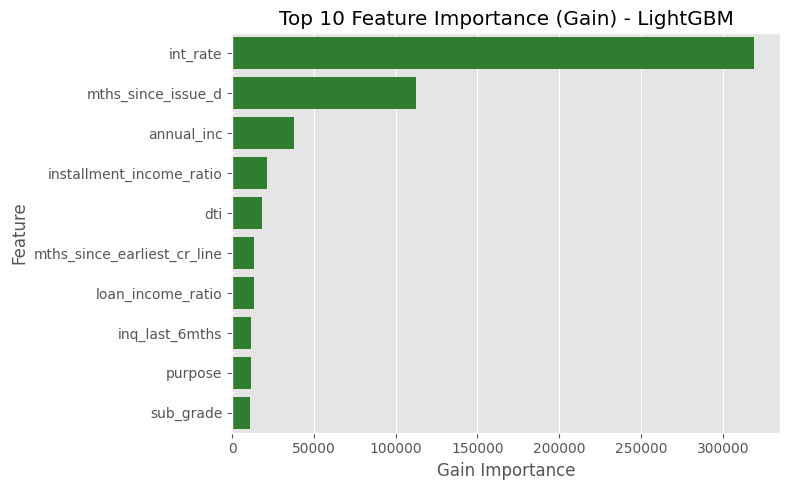

Top 10 Feature Importance (Gain) - LightGBM


,Feature,Gain Importance
3,int_rate,319007.710735
30,mths_since_issue_d,112307.643209
7,annual_inc,38056.104849
32,installment_income_ratio,21042.401800
11,dti,18480.737125
29,mths_since_earliest_cr_line,13173.188377
33,loan_income_ratio,13118.450941
13,inq_last_6mths,11663.544519
9,purpose,11588.223267
5,sub_grade,10998.851402


In [60]:
best_lgbm = lgbm_search.best_estimator_.named_steps["model"]

lgbm_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Gain Importance": best_lgbm.feature_importances_
    })
    .sort_values(
        "Gain Importance",
        ascending=False
    )
)

top10_lgbm = lgbm_importance.head(10)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top10_lgbm,
    x="Gain Importance",
    y="Feature",
    color="forestgreen",
    ax=ax
)

ax.set_title("Top 10 Feature Importance (Gain) - LightGBM")
ax.set_xlabel("Gain Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

print("Top 10 Feature Importance (Gain) - LightGBM")

display(top10_lgbm)